# Titanic

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning

In [2]:
df = pd.read_csv("../Dataset/titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [6]:
df.Cabin.mode()[0]

'B96 B98'

In [7]:
cleaned_df = df.drop('Cabin',axis = 1)

In [8]:
cleaned_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [9]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [10]:
cleaned_df.Age.unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [11]:
cleaned_df.loc[cleaned_df['Age'] < 1,'Age'] = np.nan

In [12]:
cleaned_df['Age'].unique()

array([22. , 38. , 26. , 35. ,  nan, 54. ,  2. , 27. , 14. ,  4. , 58. ,
       20. , 39. , 55. , 31. , 34. , 15. , 28. ,  8. , 19. , 40. , 66. ,
       42. , 21. , 18. ,  3. ,  7. , 49. , 29. , 65. , 28.5,  5. , 11. ,
       45. , 17. , 32. , 16. , 25. , 30. , 33. , 23. , 24. , 46. , 59. ,
       71. , 37. , 47. , 14.5, 70.5, 32.5, 12. ,  9. , 36.5, 51. , 55.5,
       40.5, 44. ,  1. , 61. , 56. , 50. , 36. , 45.5, 20.5, 62. , 41. ,
       52. , 63. , 23.5, 43. , 60. , 10. , 64. , 13. , 48. , 53. , 57. ,
       80. , 70. , 24.5,  6. , 30.5, 34.5, 74. ])

In [13]:
cleaned_df['Age'] = cleaned_df['Age'].fillna(0)

In [14]:
cleaned_df['Age'].unique()

array([22. , 38. , 26. , 35. ,  0. , 54. ,  2. , 27. , 14. ,  4. , 58. ,
       20. , 39. , 55. , 31. , 34. , 15. , 28. ,  8. , 19. , 40. , 66. ,
       42. , 21. , 18. ,  3. ,  7. , 49. , 29. , 65. , 28.5,  5. , 11. ,
       45. , 17. , 32. , 16. , 25. , 30. , 33. , 23. , 24. , 46. , 59. ,
       71. , 37. , 47. , 14.5, 70.5, 32.5, 12. ,  9. , 36.5, 51. , 55.5,
       40.5, 44. ,  1. , 61. , 56. , 50. , 36. , 45.5, 20.5, 62. , 41. ,
       52. , 63. , 23.5, 43. , 60. , 10. , 64. , 13. , 48. , 53. , 57. ,
       80. , 70. , 24.5,  6. , 30.5, 34.5, 74. ])

In [15]:
cleaned_df['Age'] = cleaned_df['Age'].astype('int64')

In [16]:
cleaned_df['Age']

0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888     0
889    26
890    32
Name: Age, Length: 891, dtype: int64

In [17]:
cleaned_df['Age'] = cleaned_df['Age'].replace(0,cleaned_df['Age'].value_counts().index[1])

In [18]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 76.7 KB


In [19]:
cleaned_df['Embarked'] = cleaned_df['Embarked'].fillna(cleaned_df['Embarked'].mode()[0])

In [20]:
cleaned_df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [21]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 76.7 KB


In [22]:
cleaned_df.Sex.unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

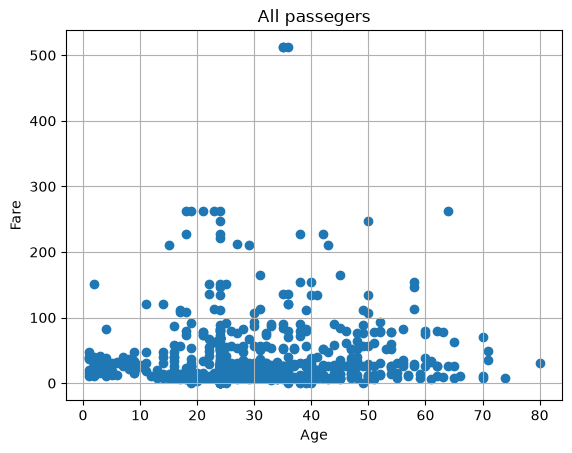

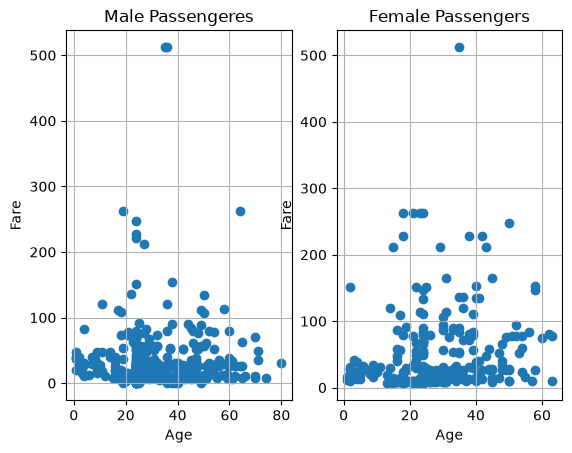

In [23]:
plt.scatter(cleaned_df['Age'],cleaned_df['Fare'])
plt.grid('True')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('All passegers')
plt.show()
plt.subplot(1,2,1)
plt.scatter(cleaned_df.loc[cleaned_df['Sex'] == 'male','Age'],cleaned_df.loc[cleaned_df['Sex'] == 'male','Fare'])
plt.grid('True')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Male Passengeres')
plt.subplot(1,2,2)
plt.scatter(cleaned_df.loc[cleaned_df['Sex'] == 'female','Age'],cleaned_df.loc[cleaned_df['Sex'] == 'female','Fare'])
plt.grid('True')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Female Passengers')
plt.show()

In [24]:
cleaned_df[cleaned_df['Sex'] == 'female'].groupby('Embarked')['Sex'].count()

Embarked
C     73
Q     36
S    205
Name: Sex, dtype: int64

In [25]:
cleaned_df[cleaned_df['Sex'] == 'male'].groupby('Embarked')['Sex'].count()

Embarked
C     95
Q     41
S    441
Name: Sex, dtype: int64

In [26]:
male_df = cleaned_df[cleaned_df['Sex'] == 'male']
female_df = cleaned_df[cleaned_df['Sex'] == 'female']

NameError: name 'cleaned' is not defined

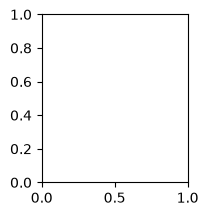

In [27]:
plt.subplot(2,3,1)
plt.plot(cleaned_df.loc[cleaned_df['Sex'] == 'male',cleaned])

### How many Survived and did not Survived

In [ ]:
cleaned_df.loc[cleaned_df['Survived'] == 0,'Survived'].count()

In [ ]:
plt.bar(['survived','not survived'],[cleaned_df.loc[cleaned_df['Survived'] == 1,'Survived'].count(),cleaned_df.loc[cleaned_df['Survived'] == 0,'Survived'].count()]
)

plt.xlabel = 'Survived'
plt.ylable = 'Count'
plt.title = 'Survial'
plt.legend()
plt.show()

### How did survival differ among passengers based on their gender

In [ ]:
import seaborn as sns

In [ ]:
male = cleaned_df[cleaned_df['Sex'] == 'male']
female = cleaned_df[cleaned_df['Sex'] == 'female']
plt.bar(['Male','Female'],[
    (male.loc[male['Survived'] == 1,'Survived'].count()/len(male))*100,
    (female.loc[female['Survived'] == 1,'Survived'].count()/len(female))*100
],color = 'red')
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.title("Female Survival Analysis")
plt.show()

In [ ]:
male = cleaned_df[cleaned_df['Sex'] == 'male']
female = cleaned_df[cleaned_df['Sex'] == 'female']
plt.bar(['Male','Female'],[
    (male['Survived'] == 1).mean()*100,
    (female['Survived']== 1).mean()*100
])
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.title("Female Survival Analysis")
plt.show()

In [ ]:
temp = cleaned_df.groupby('Sex')['Survived']
plt.bar(['Male','Female'],[
    temp.get_group('male').mean()*100,
    temp.get_group('female').mean()*100
])
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.title("Female Survival Analysis")
plt.show()

In [ ]:
survival_rate = cleaned_df.groupby('Sex')['Survived'].agg('mean')
x = survival_rate.index
y = survival_rate.values * 100
sns.barplot(x=x,y=y)
plt.xlabel('Gender')
plt.ylabel('Survival Rate %')
plt.title('Survival Chart')
plt.show()

In [ ]:
sns.barplot(
    data = cleaned_df,
    x='Pclass',
    y='Survived',
    hue ='Sex',
)

In [ ]:
female.loc[female['Survived'] == 1,'Survived'].count()

In [ ]:
(male['Survived'] == 1).mean() * 100

In [ ]:
len(male)

In [ ]:
temp = cleaned_df.groupby('Sex')['Survived']
print(temp.get_group('male').mean())

### Which Passenger class has the highest survial rates

In [ ]:
cleaned_df.head()

In [ ]:
cleaned_df.info()

In [ ]:
class_rate = cleaned_df.groupby('Pclass')['Survived'].mean() * 100
x = class_rate.index
y = class_rate.values
x = x.astype('str')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Class Based Survival Rates')
plt.bar(x,y)
plt.show()

In [ ]:
sns.barplot(x=x,y=y)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate %')
plt.title('Class Based Survival Rates')
plt.show()

### Analyze how survival rate differs between different age groups.
* 1-12 = Child
* 13-19 = Teen
* 20-59 = Adult
* 60+ = Senior

In [ ]:
temp = cleaned_df.copy()

In [ ]:
temp['Group'] = np.nan

In [ ]:
temp.head()

In [ ]:
temp[temp['Age'] <= 12]

In [ ]:
temp['Group'] = temp['Group'].astype('object')

In [ ]:
temp.loc[temp['Age'] <= 12, 'Group'] = 'Child'
temp.loc[(temp['Age']>12) & (temp['Age'] <= 19),'Group'] = 'Teen'
temp.loc[(temp['Age'] > 19)&(temp['Age'] <= 59),'Group'] = 'Adult'
temp.loc[(temp['Age'] > 59) , 'Group'] = 'Senior'

In [ ]:
age_survived = temp.groupby('Group')['Survived'].mean() * 100
x = age_survived.index.astype('str')
y = age_survived.values
plt.bar(x,y)
plt.xlabel('Age Group')
plt.ylabel('Survival Rate %')
plt.title('Age Wise Survival')
plt.show()

In [ ]:
sns.barplot(x=x,y=y)
plt.xlabel('Age Group')
plt.ylabel('Survival Rate %')
plt.title('Age Based Survival Rate')
plt.show()

In [ ]:
relation = cleaned_df[['Pclass','Survived']].corr()
sns.heatmap(relation,annot=True)

In [ ]:
sns.countplot(
    data = cleaned_df,
    x = 'Pclass',
    hue = 'Survived'
)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Count')
plt.title('Survival Analysis on Classes')
plt.legend(
    labels=['Dead','Survived']
)
plt.show()

### What percentage of passengers survived in each passenger class?

In [ ]:
temp = cleaned_df.groupby('Pclass')['Survived'].mean() * 100
x = temp.index.astype(str)
y = temp.values
plt.bar(x,y)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate %')
plt.title('Survial Rate on Passenger Class')
plt.show()

In [ ]:
sns.barplot(x=x,y=y)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate %')
plt.title('Passenger Class Survival Rate %')
plt.show()

### Create a visualization that allows you to compare survival rates for male and female passengers within each passenger class.

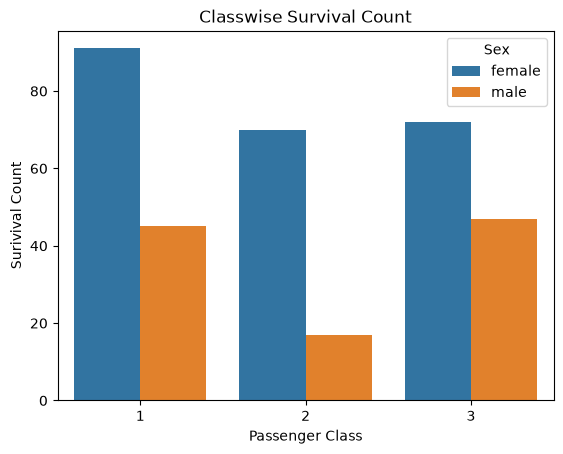

In [39]:
y = cleaned_df.groupby('Sex')
sns.countplot(data = cleaned_df[cleaned_df['Survived'] == 1],
           x = 'Pclass',
           hue = 'Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Surivival Count')
plt.title('Classwise Survival Count')
plt.show()

Text(0.5, 1.0, 'Passenger Class Gender Survival Rate')

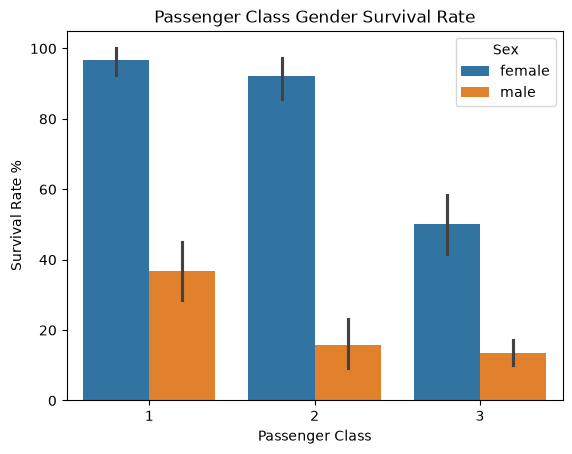

In [41]:
sns.barplot(
    data = cleaned_df,
    x = 'Pclass',
    y = 'Survived',
    hue = 'Sex',
    estimator = lambda x : x.mean()*100
)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate %')
plt.title('Passenger Class Gender Survival Rate')

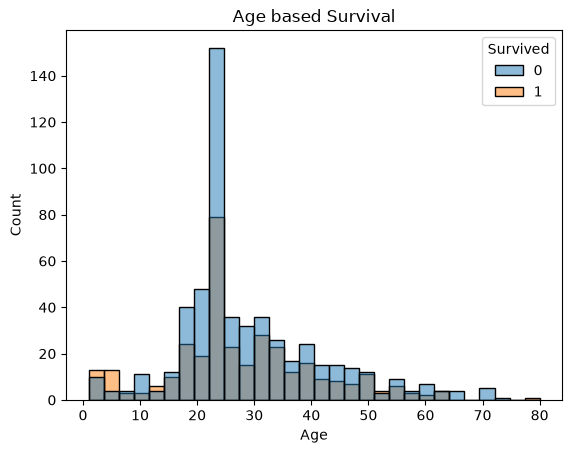

In [47]:
sns.histplot(
    data = cleaned_df,
    x='Age',
    hue = 'Survived',
    bins = 30)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age based Survival')
plt.show()

<Axes: >

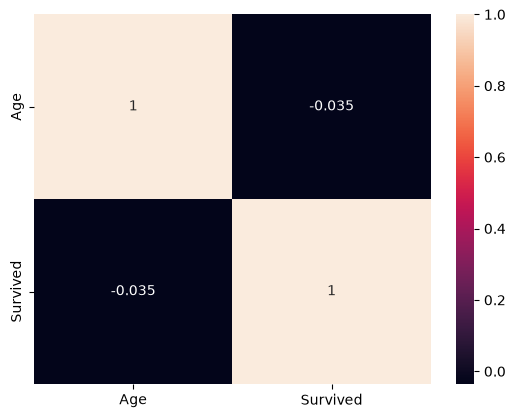

In [58]:
relate = cleaned_df[['Age','Survived']].corr()
sns.heatmap(
    data = relate,
    annot = True,
)

### Create a visualization that compares the distribution of Fare for passengers who survived and passengers who did not survive.

<Axes: xlabel='Fare', ylabel='Count'>

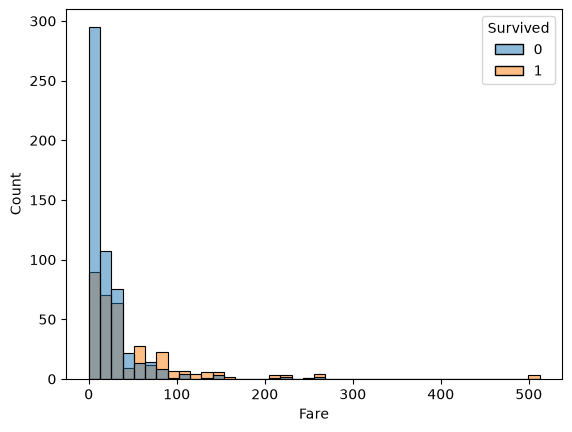

In [64]:
sns.histplot(
    data = cleaned_df,
    x = 'Fare',
    hue = 'Survived',
    bins = 40
)

### Investigate whether the number of siblings/spouses (SibSp) a passenger had was associated with survival.

### Create a visualization that allows you to compare the survival outcomes across different SibSp values.

In [67]:
cleaned_df['SibSp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

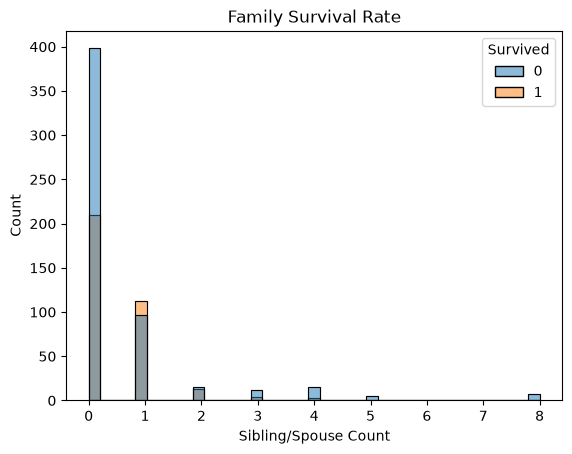

In [69]:
sns.histplot(
    data = cleaned_df,
    hue = 'Survived',
    x = 'SibSp'
)
plt.xlabel('Sibling/Spouse Count')
plt.ylabel('Count')
plt.title('Family Survival Rate')
plt.show()

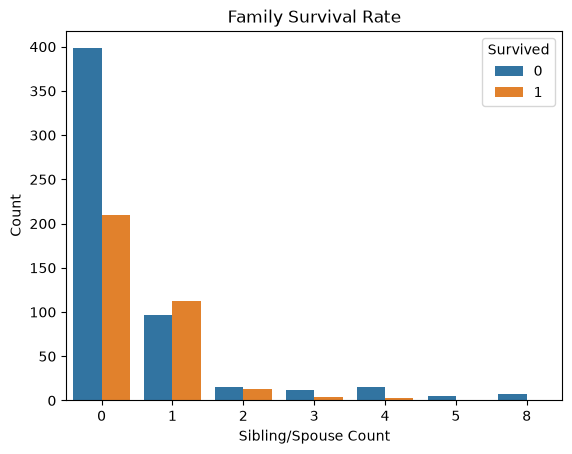

In [71]:
sns.countplot(
    data = cleaned_df,
    hue = 'Survived',
    x = 'SibSp'
)
plt.xlabel('Sibling/Spouse Count')
plt.ylabel('Count')
plt.title('Family Survival Rate')
plt.show()

### Investigate whether the number of parents/children (Parch) a passenger had aboard was associated with their survival.

### Create a visualization that compares the survivors and non-survivors for each Parch value.